# Explore EMA

In [1]:
# imports
from importlib import reload
from importlib.resources import files
import os
import numpy as np

from scipy.optimize import curve_fit

import pandas
import seaborn as sns
from matplotlib import pyplot as plt

from scipy.interpolate import interp1d

from ocpy.hydrolight import loisel23
from ocpy.utils import plotting as oc_plotting
from ocpy.satellites import pace as sat_pace


In [2]:
%matplotlib ipympl

# Load up Loisel+2023 Hydrolight dataset

In [3]:
ds = loisel23.load_ds(4,0)

In [4]:
l23_wave = ds.Lambda.data
l23_Rrs = ds.Rrs.data
all_a = ds.a.data
all_bb = ds.bb.data
all_adg = ds.ag.data + ds.ad.data
all_ad = ds.ad.data
all_ag = ds.ag.data
all_aph = ds.aph.data
all_anw = ds.anw.data

In [14]:
l23_wave.min(), l23_wave.max()

(np.float32(350.0), np.float32(750.0))

## $L_w$

In [5]:
i412 = np.argmin(np.abs(l23_wave-412.))
i440 = np.argmin(np.abs(l23_wave-440.))
i670 = np.argmin(np.abs(l23_wave-670.))

In [15]:
Lw_412 = ds.Lw[:, i412]
Lw_670 = ds.Lw[:, i670]
# These are extrapolations
Lw_320 = ds.Lw[:, 0]
Lw_780 = ds.Lw[:, -1]

## Pure sea-water

In [7]:
aw = all_a[0] - all_anw[0]

# $a_{\rm cdom}$ histogram at 440nm

In [8]:
acdom_440 = all_ag[:,i440]

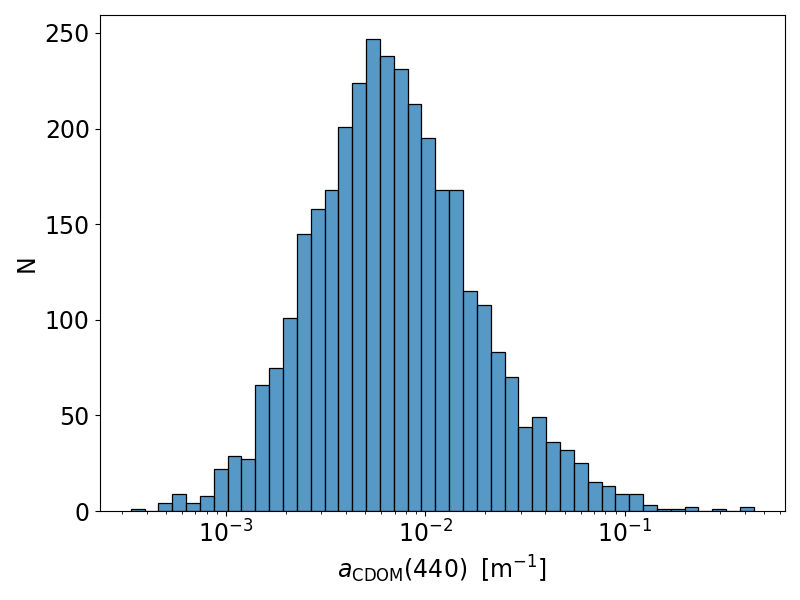

In [9]:
fig = plt.figure(figsize=(8,6))
ax = plt.gca()

sns.histplot(acdom_440, log_scale=(True,False))
#
ax.set_xlabel(r'$a_{\rm CDOM}(440) \;\; \rm [m^{-1}]$')
ax.set_ylabel('N')
oc_plotting.set_fontsize(ax, 17.)
#
#ax.set_xscale('log')
plt.tight_layout()
plt.show()

# EMA Coefficients

## Houskeeper 2021

In [10]:
## OCEAN
A_412 = 0.242
B_412 = -0.787
## GLOBC
A_412_G = 0.242
B_412_G = -0.961
## NOMAD
A_412_N = 0.285
B_412_N = -0.638

## Calculate $a_{\rm CDOM} (440)$

In [11]:
Lambda_46 = Lw_412 / Lw_670
#
acdom_46 = A_412 * Lambda_46**B_412
acdom_46_G = A_412_G * Lambda_46**B_412_G
acdom_46_N = A_412_N * Lambda_46**B_412_N

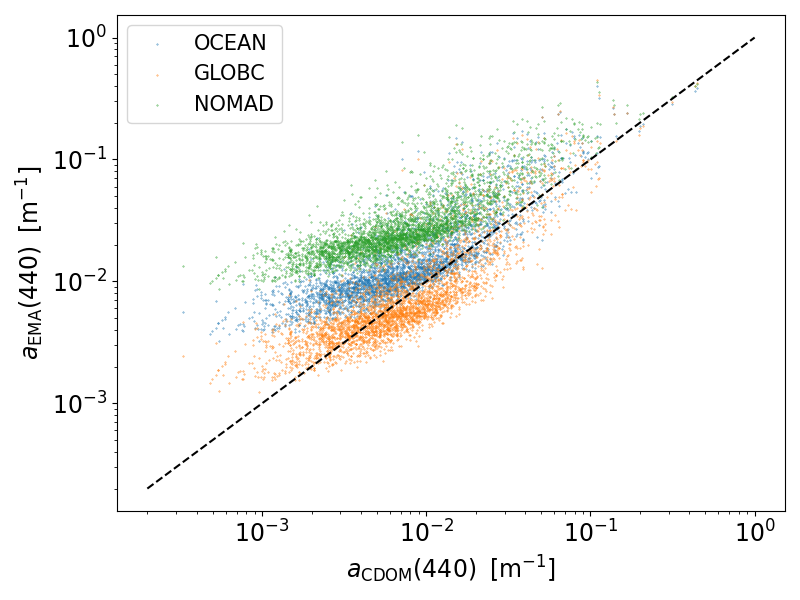

In [12]:
fig = plt.figure(figsize=(8,6))
ax = plt.gca()
#
ax.scatter(acdom_440, acdom_46, marker='o', s=0.1, label='OCEAN')
ax.scatter(acdom_440, acdom_46_G, marker='o', s=0.1, label='GLOBC')
ax.scatter(acdom_440, acdom_46_N, marker='o', s=0.1, label='NOMAD')
#
ax.legend(fontsize=15.)
oc_plotting.set_fontsize(ax, 17.)
# Label
ax.set_xlabel(r'$a_{\rm CDOM}(440) \;\; \rm [m^{-1}]$')
ax.set_ylabel(r'$a_{\rm EMA}(440) \;\; \rm [m^{-1}]$')
# One-to-one
ax.plot([2e-4, 1], [2e-4, 1.], 'k--')
#
ax.set_xscale('log')
ax.set_yscale('log')
#
plt.tight_layout()
plt.show()

----

# Let's go bluer (and redder)!

In [13]:
## OCEAN
A_37 = 0.281
B_37 = -0.542
## GLOBC
A_37_G = 0.259
B_37_G = -0.558

## Calculate

In [16]:
Lambda_37 = Lw_320 / Lw_780
#
acdom_37= A_37 * Lambda_37**B_37
acdom_37G = A_37_G * Lambda_37**B_37_G

## Plot

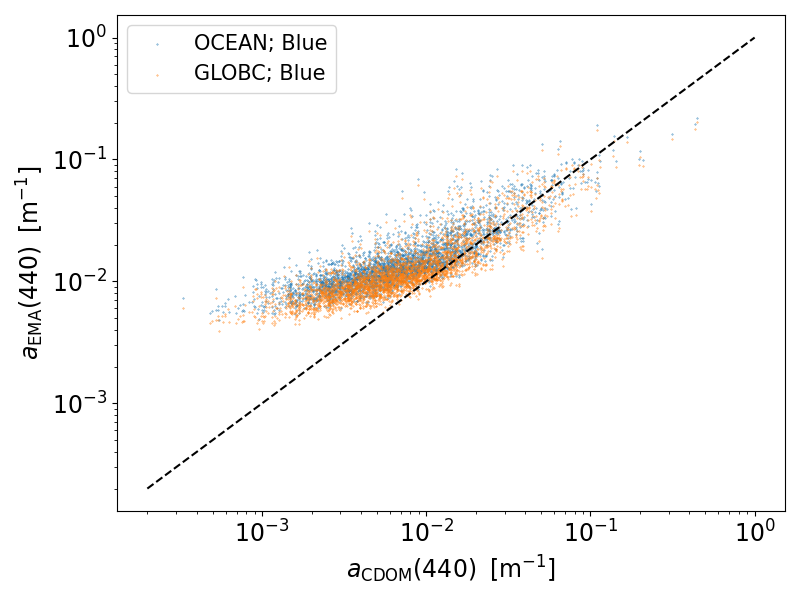

In [18]:
fig = plt.figure(figsize=(8,6))
ax = plt.gca()
#
ax.scatter(acdom_440, acdom_37, marker='o', s=0.1, label='OCEAN; Blue')
ax.scatter(acdom_440, acdom_37G, marker='o', s=0.1, label='GLOBC; Blue')
#
ax.legend(fontsize=15.)
oc_plotting.set_fontsize(ax, 17.)
# Label
ax.set_xlabel(r'$a_{\rm CDOM}(440) \;\; \rm [m^{-1}]$')
ax.set_ylabel(r'$a_{\rm EMA}(440) \;\; \rm [m^{-1}]$')
# One-to-one
ax.plot([2e-4, 1], [2e-4, 1.], 'k--')
#
ax.set_xscale('log')
ax.set_yscale('log')
#
plt.tight_layout()
plt.show()